In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!pip install openpyxl 

In [3]:
 #for opening excel file this library is needed

In [4]:
import pandas as pd

print(pd.ExcelFile(r"C:\Users\Tushar Wadkar\updated_matches.xlsx").sheet_names)


['pivot_table', 'matches']


In [5]:
df = pd.read_excel(r"C:\Users\Tushar Wadkar\updated_matches.xlsx", sheet_name="matches")
df.head(5)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,Tushar Menon,Jatin Sapru


In [7]:
df.isnull().sum()

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64

In [8]:
df.describe()
df['winner'].value_counts()

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Draw                             4
Name: count, dtype: int64

In [9]:
df.describe()
df['player_of_match'].value_counts()

player_of_match
CH Gayle          21
AB de Villiers    20
DA Warner         17
MS Dhoni          17
RG Sharma         17
                  ..
Imran Tahir        1
K Paul             1
K Ahmed            1
S Gill             1
S Hetmyer          1
Name: count, Length: 227, dtype: int64

In [10]:
df.describe()

,id,season,date,win_by_runs,win_by_wickets
count,756.000000,756.000000,756,756.000000,756.000000
mean,1792.178571,2013.444444,2013-10-07 06:22:51.428571392,13.283069,3.350529
min,1.000000,2008.000000,2008-04-18 00:00:00,0.000000,0.000000
25%,189.750000,2011.000000,2011-04-16 00:00:00,0.000000,0.000000
50%,378.500000,2013.000000,2013-05-09 12:00:00,0.000000,4.000000
75%,567.250000,2016.000000,2016-05-18 06:00:00,19.000000,6.000000
max,11415.000000,2019.000000,2019-05-12 00:00:00,146.000000,10.000000
std,3464.478148,3.366895,NaN,23.471144,3.387963


In [11]:
wins = df.groupby(['season', 'winner']).size().reset_index(name='total_wins')

In [12]:
top_winners = wins.loc[wins.groupby('season')['total_wins'].idxmax()]
print(top_winners)

    season                 winner  total_wins
6     2008       Rajasthan Royals          13
10    2009       Delhi Daredevils          10
21    2010         Mumbai Indians          11
24    2011    Chennai Super Kings          11
39    2012  Kolkata Knight Riders          12
48    2013         Mumbai Indians          13
55    2014        Kings XI Punjab          12
61    2015    Chennai Super Kings          10
77    2016    Sunrisers Hyderabad          11
82    2017         Mumbai Indians          12
86    2018    Chennai Super Kings          11
99    2019         Mumbai Indians          11


In [13]:
df['bat_first_win'] = (df['win_by_runs'] > 0).astype(int)
df['bowl_first_win'] = (df['win_by_wickets'] > 0).astype(int)
df['draw_match'] = ((df['win_by_runs'] == 0) & (df['win_by_wickets'] == 0)).astype(int)

result = df.groupby('venue').agg(
    total_matches=('venue', 'count'),
    bat_first_wins=('bat_first_win', 'sum'),
    bowl_first_wins=('bowl_first_win', 'sum'),
    draw_matches=('draw_match', 'sum')  
)
result = result.reset_index()
valid_matches = result['total_matches'] - result['draw_matches']

result['bat_first_win_percent'] = (result['bat_first_wins'] / valid_matches) * 100
result['bowl_first_win_percent'] = (result['bowl_first_wins'] / valid_matches) * 100

result['bat_first_win_percent'] = result['bat_first_win_percent'].round(2)
result['bowl_first_win_percent'] = result['bowl_first_win_percent'].round(2)

result

,venue,total_matches,bat_first_wins,bowl_first_wins,draw_matches,bat_first_win_percent,bowl_first_win_percent
0,ACA-VDCA Stadium,2,0,2,0,0.00,100.00
1,Barabati Stadium,7,4,3,0,57.14,42.86
2,Brabourne Stadium,11,6,5,0,54.55,45.45
3,Buffalo Park,3,2,1,0,66.67,33.33
4,De Beers Diamond Oval,3,1,2,0,33.33,66.67
5,Dr DY Patil Sports Academy,17,7,10,0,41.18,58.82
6,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,11,7,4,0,63.64,36.36
7,Dubai International Cricket Stadium,7,3,4,0,42.86,57.14
8,Eden Gardens,77,32,45,0,41.56,58.44
9,Feroz Shah Kotla,67,33,33,1,50.00,50.00


In [14]:
top_venues = df['venue'].value_counts().head(10).reset_index()
top_venues.columns = ['venue', 'total-matches']

print(top_venues)

                                        venue  total-matches
0                                Eden Gardens             77
1                            Wankhede Stadium             73
2                       M Chinnaswamy Stadium             73
3                            Feroz Shah Kotla             67
4   Rajiv Gandhi International Stadium, Uppal             56
5             MA Chidambaram Stadium, Chepauk             49
6                      Sawai Mansingh Stadium             47
7  Punjab Cricket Association Stadium, Mohali             35
8     Maharashtra Cricket Association Stadium             21
9                  Subrata Roy Sahara Stadium             17


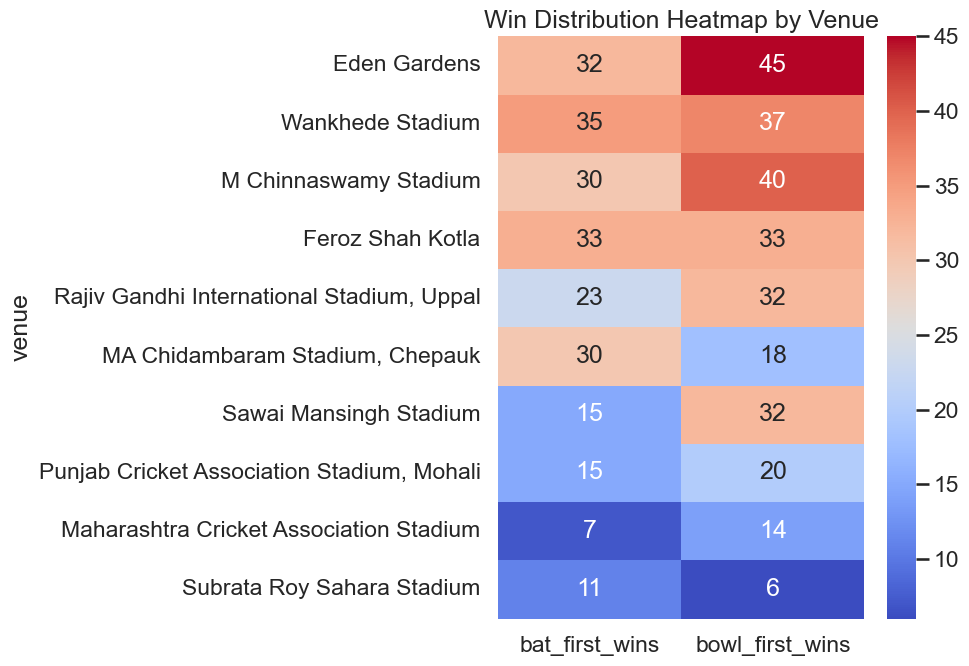

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")     # clean background
sns.set_context("talk")        # bigger fonts

heatmap_data = top_venues.set_index('venue')[['bat_first_wins', 'bowl_first_wins']]

plt.figure(figsize=(10,7))

sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="coolwarm")

plt.title("Win Distribution Heatmap by Venue")
plt.tight_layout()
plt.show()

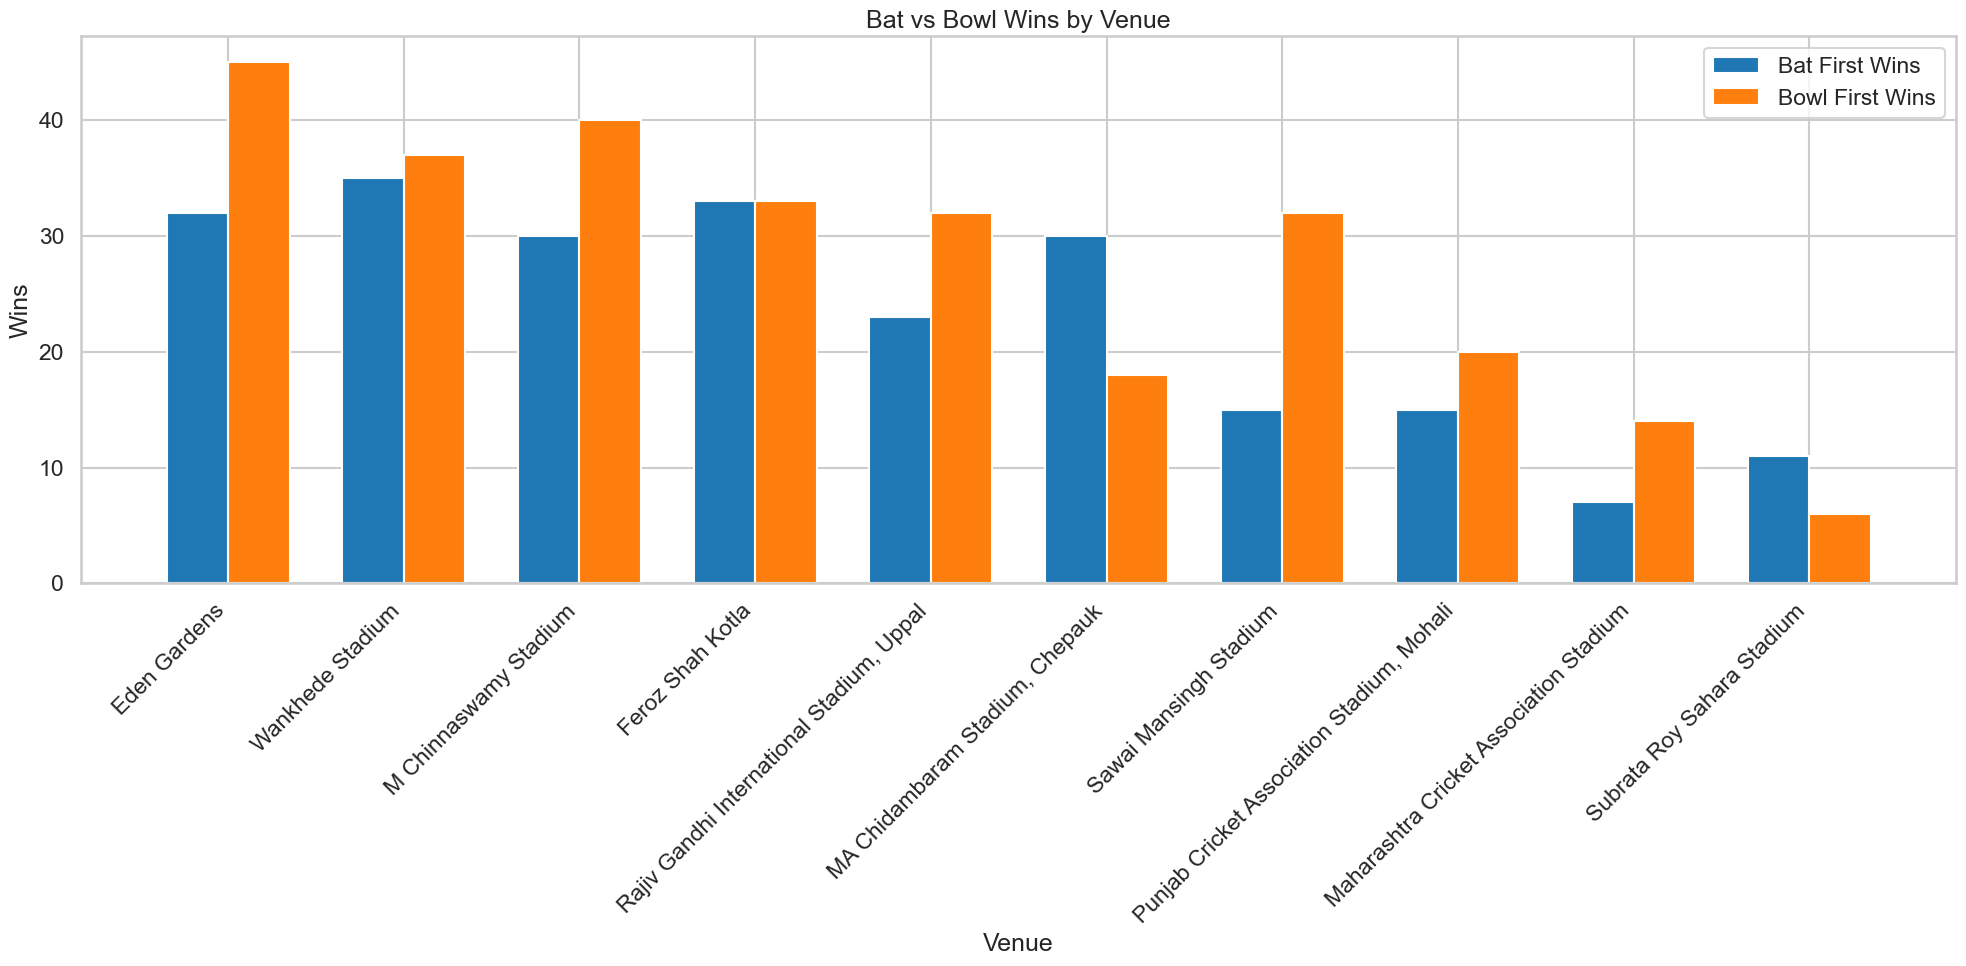

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Grouping data
result = df.groupby('venue').agg(
    total_matches=('venue', 'count'),
    bat_first_wins=('bat_first_win', 'sum'),
    bowl_first_wins=('bowl_first_win', 'sum')
).reset_index()

# Top 10 venues
top_venues = result.sort_values('total_matches', ascending=False).head(10)

# Data
venues = top_venues['venue']
bat_wins = top_venues['bat_first_wins']
bowl_wins = top_venues['bowl_first_wins']

# X positions
x = np.arange(len(venues))
width = 0.35  # bar width

# Plot
plt.figure(figsize=(20,10))

plt.bar(x - width/2, bat_wins, width, label='Bat First Wins')
plt.bar(x + width/2, bowl_wins, width, label='Bowl First Wins')

# Labels exactly centered under grouped bars
plt.xticks(x, venues, rotation=45, ha='right')

plt.title("Bat vs Bowl Wins by Venue")
plt.xlabel("Venue")
plt.ylabel("Wins")

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
df.columns = df.columns.str.lower()

In [28]:
df.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'winner', 'win_by_runs', 'win_by_wickets',
       'player_of_match', 'venue', 'umpire1', 'umpire2', 'bat_first_win',
       'bowl_first_win', 'draw_match'],
      dtype='object')

In [18]:
df.shape

(756, 19)

In [19]:

df.head(5)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,bat_first_win,bowl_first_win,draw_match
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,1,0,0
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,0,1,0
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,0,1,0
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,0,1,0
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,Tushar Menon,Jatin Sapru,1,0,0


In [20]:
# matches where teams chased (2nd innings win scenario)
chasing_matches = df[df['win_by_wickets'] > 0]

# wins while chasing
chasing_wins = chasing_matches['winner'].value_counts()

# total matches played (as team2 = chasing team)
chasing_played = df['team2'].value_counts()

# combine
chasing_table = pd.DataFrame({
    'matches_played': chasing_played,
    'chasing_wins': chasing_wins
}).fillna(0)

# win %
chasing_table['win_percentage'] = (chasing_table['chasing_wins'] / chasing_table['matches_played']) * 100

# top 3
chasing_table = chasing_table.sort_values('chasing_wins', ascending=False).head(3)

chasing_table

,matches_played,chasing_wins,win_percentage
Kolkata Knight Riders,95,56,58.947368
Mumbai Indians,86,50,58.139535
Chennai Super Kings,75,48,64.000000


In [21]:
# matches where teams defended (1st innings win scenario)
defending_matches = df[df['win_by_runs'] > 0]

# wins while defending
defending_wins = defending_matches['winner'].value_counts()

# total matches played (as team1 = batting first)
defending_played = df['team1'].value_counts()

# combine
defending_table = pd.DataFrame({
    'matches_played': defending_played,
    'defending_wins': defending_wins
}).fillna(0)

# win %
defending_table['win_percentage'] = (defending_table['defending_wins'] / defending_table['matches_played']) * 100

# top 3
defending_table = defending_table.sort_values('defending_wins', ascending=False).head(3)

defending_table

,matches_played,defending_wins,win_percentage
Mumbai Indians,101,57,56.435644
Chennai Super Kings,89,52,58.426966
Kings XI Punjab,91,38,41.758242


In [22]:
# total matches played by each team
matches_played = pd.concat([df['team1'], df['team2']]).value_counts()

# total wins
wins = df['winner'].value_counts()

# combine
performance = pd.DataFrame({
    'matches_played': matches_played,
    'wins': wins
}).fillna(0)

# convert to int
performance['matches_played'] = performance['matches_played'].astype(int)
performance['wins'] = performance['wins'].astype(int)

# win %
performance['win_percentage'] = ((performance['wins'] / performance['matches_played']) * 100).round(2)

performance = performance.sort_values('win_percentage', ascending=False)

performance.head()

,matches_played,wins,win_percentage
Draw,0,4,inf
Delhi Capitals,16,10,62.50
Chennai Super Kings,164,100,60.98
Mumbai Indians,187,109,58.29
Sunrisers Hyderabad,108,58,53.70


In [23]:
# Step 1: Clean data
df_clean = df[df['winner'].notna()]

# Step 2: Total matches played
matches_played = pd.concat([df_clean['team1'], df_clean['team2']]).value_counts()

# Step 3: Wins
wins = df_clean['winner'].value_counts()

# Step 4: Chasing wins
ch_wins = df_clean[df_clean['win_by_wickets'] > 0]['winner'].value_counts()

# Step 5: Defending wins
def_wins = df_clean[df_clean['win_by_runs'] > 0]['winner'].value_counts()

# Step 6: Create table (IMPORTANT 🔥)
final = pd.DataFrame({
    'matches_played': matches_played,
    'total_wins': wins,
    'chasing_wins': ch_wins,
    'defending_wins': def_wins
}).fillna(0)

# Step 7: Convert to int
final = final.astype(int)

# Create batting order
df_clean['bat_first'] = df_clean.apply(
    lambda x: x['toss_winner'] if x['toss_decision'] == 'bat' 
    else (x['team1'] if x['toss_winner'] != x['team1'] else x['team2']),
    axis=1
)

df_clean['bowl_first'] = df_clean.apply(
    lambda x: x['team2'] if x['bat_first'] == x['team1'] else x['team1'],
    axis=1
)

# Matches played
ch_played = df_clean['bowl_first'].value_counts()
def_played = df_clean['bat_first'].value_counts()

# Add to table
final['chasing_matches'] = ch_played
final['defending_matches'] = def_played

final = final.fillna(0)
final[['chasing_matches','defending_matches']] = final[['chasing_matches','defending_matches']].astype(int)

final['win_percentage'] = ((final['total_wins'] / final['matches_played']) * 100).round(2)

final['chasing_win_pct'] = ((final['chasing_wins'] / final['chasing_matches']) * 100).round(2)

final['defending_win_pct'] = ((final['defending_wins'] / final['defending_matches']) * 100).round(2)

final



,matches_played,total_wins,chasing_wins,defending_wins,chasing_matches,defending_matches,win_percentage,chasing_win_pct,defending_win_pct
Chennai Super Kings,164,100,48,52,75,89,60.98,64.00,58.43
Deccan Chargers,75,29,11,18,32,43,38.67,34.38,41.86
Delhi Capitals,16,10,6,3,10,6,62.50,60.00,50.00
Delhi Daredevils,161,67,42,25,89,72,41.61,47.19,34.72
Draw,0,4,0,0,0,0,inf,NaN,NaN
Gujarat Lions,30,13,12,1,16,14,43.33,75.00,7.14
Kings XI Punjab,176,82,42,38,85,91,46.59,49.41,41.76
Kochi Tuskers Kerala,14,6,4,2,7,7,42.86,57.14,28.57
Kolkata Knight Riders,178,92,56,36,95,83,51.69,58.95,43.37
Mumbai Indians,187,109,50,57,86,101,58.29,58.14,56.44


In [24]:
!pip install mysql-connector-python sqlalchemy

In [25]:
matches_df = pd.read_excel("updated_matches.xlsx", sheet_name="matches")
pivot_df = pd.read_excel("updated_matches.xlsx", sheet_name="pivot_table")

In [30]:
import pandas as pd
from sqlalchemy import create_engine

# Step 1: Read ONLY the 'matches' sheet
matches_df = pd.read_excel("updated_matches.xlsx", sheet_name="matches")

# Step 2: Create MySQL connection using SQLAlchemy
username = "root"
password = "tushar21"
host = "localhost"
port = "3306"
database = "ipl_db"

engine = create_engine(f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}")

# Step 3: Upload dataframe to MySQL (ONLY matches sheet)
matches_df.to_sql(
    name="matches",       # table name in MySQL
    con=engine,
    if_exists="replace",  # options: replace / append / fail
    index=False
)

print("✅ Matches sheet successfully uploaded to MySQL!")

✅ Matches sheet successfully uploaded to MySQL!
